In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
ds = pd.read_csv("../src/data/data.csv")

In [4]:
ds.shape

(17337, 3)

In [5]:
ds = ds.iloc[:8000, :]
ds

,Unnamed: 0,cleaned_review,sentiments
0,0,i wish would have gotten one earlier love it a...,1
1,1,i ve learned this lesson again open the packag...,0
2,2,it is so slow and lags find better option,0
3,3,roller ball stopped working within months of m...,0
4,4,i like the color and size but it few days out ...,0
...,...,...,...
7995,7997,the right click button stopped working within ...,2
7996,7998,although it pretty it works great and love th...,1
7997,7999,i have many wireless mouses mice trying to fin...,1
7998,8000,best mouse ve ever bought so glad got it perfe...,1


In [6]:
X, y = ds["cleaned_review"], ds["sentiments"]

In [7]:
ds["sentiments"].value_counts()

sentiments
1    3619
0    3435
2     946
Name: count, dtype: int64

In [8]:
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

In [9]:
X_temp_train, X_test, y_temp_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state = 42)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X_temp_train, y_temp_train, test_size = 0.2, stratify = y_temp_train, random_state = 42)  

In [11]:
BATCH_SIZE = 64

In [12]:
vectorizer = TfidfVectorizer(
    max_features = 5000,
    ngram_range = (1,2)
)

In [13]:
X_train_tfid = vectorizer.fit_transform(X_train)
X_val_tfid = vectorizer.transform(X_val)
X_test_tfid = vectorizer.transform(X_test)

In [14]:
X_train_tensor = torch.tensor(X_train_tfid.toarray(), dtype = torch.float32)
X_val_tensor = torch.tensor(X_val_tfid.toarray(), dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_tfid.toarray(), dtype = torch.float32)

In [15]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.long)

In [16]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [17]:
train_loader = DataLoader(train_dataset, shuffle = True, batch_size=32)
val_loader = DataLoader(val_dataset , shuffle = False, batch_size = 32)
test_loader = DataLoader(test_dataset, shuffle = False, batch_size= 32)

In [18]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim=5000, num_classes = 3):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, num_classes),
        )

    def forward(self, X_batch):
        return self.seq(X_batch)

In [19]:
def train_one_epochs(model, loader, optimizer, criterion, device ):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x_batch, y_batch in loader:
        x = x_batch.to(device, non_blocking = True)
        y = y_batch.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x_batch, y_batch in loader:
        x = x_batch.to(device, non_blocking = True)
        y = y_batch.to(device, non_blocking = True)
        
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        preds = logits.argmax(dim = 1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss/len(loader), total_correct/total_samples

In [21]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)

In [22]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs = 30):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    early_stopping = EarlyStopping(patience = 5)


    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epochs(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pt")
        
        if early_stopping.step(val_acc, model):
            print(f"Ранняя остановка на эпохе {epoch}")
            early_stopping.restore_best(model)
            break

    return history

In [23]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

    ax1.plot(history["train_loss"], label = "Train Loss")
    ax1.plot(history["val_loss"], label = "Val Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.grid(True)
    ax1.legend()
    ax1.set_title("Loss")


    ax2.plot(history["train_acc"], label = "Train Accuracy")
    ax2.plot(history["val_acc"], label = "Val Accuracy")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.grid(True)
    ax2.legend()
    ax2.set_title("Accuracy")

    plt.tight_layout()
    plt.show()

In [24]:
input_dim = X_train_tensor.shape[1]
text_classifier = TextClassifier(input_dim, 3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(text_classifier.parameters(), lr = 1e-3, weight_decay=1e-4)


In [25]:
history = fit(text_classifier, train_loader, val_loader, optimizer, criterion,device, epochs=30)

Ранняя остановка на эпохе 13


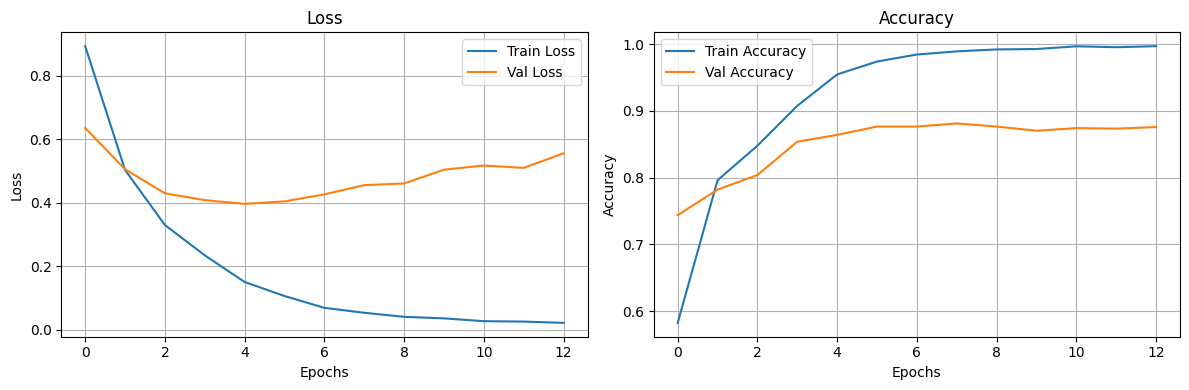

In [26]:
plot_history(history)

In [27]:
# def predict(model, dataloader, device, return_probs = False):

#     model.eval()
        
#     all_predictions = []
#     all_probabilities = []
#     all_labels = []

#     with torch.no_grad():
#         for x_batch, y_batch in datalaoader:
#             x = x_batch.to(device, non_blocking=True)
#             y = y_batch.to(device, non_blocking=True)
            
#             logits = model(x)
            
#             probs = torch.softmax(logits, dim=1)
            
#             preds = torch.argmax(logits, dim=1)
            
#             all_predictions.extend(preds.cpu().numpy())
#             all_probabilities.extend(probs.cpu().numpy())
#             all_labels.extend(y.cpu().numpy())
    
#     if return_probs:
#         return np.array(all_predictions), np.array(all_probabilities), np.array(all_labels)
#     else:
#         return np.array(all_predictions), np.array(all_labels)


In [28]:
# def show_predictions(model, dataloader, device, class_names, num_samples=10):
#     """
#     Показать предсказания модели на нескольких примерах
    
#     Args:
#         model: обученная модель
#         dataloader: DataLoader с данными
#         device: устройство
#         class_names: список названий классов
#         num_samples: количество примеров для показа
#     """
#     model.eval()
    
#     # Получаем предсказания
#     predictions, probabilities, labels = predict(model, dataloader, device, return_probs=True)
    
#     # Берем первые num_samples примеров
#     n = min(num_samples, len(predictions))
    
#     print("\n" + "="*80)
#     print("ПРЕДСКАЗАНИЯ МОДЕЛИ")
#     print("="*80)
    
#     correct_count = 0
#     for i in range(n):
#         pred_class = predictions[i]
#         true_class = labels[i]
#         confidence = probabilities[i][pred_class]
        
#         is_correct = (pred_class == true_class)
#         if is_correct:
#             correct_count += 1
        
#         print(f"\n{i+1}. Истинная: {class_names[true_class]:12}"
#               f"Предсказанная: {class_names[pred_class]:12}"
#               f"Уверенность: {confidence:.2%}")
#         print(f"   {'✅ ВЕРНО' if is_correct else '❌ НЕВЕРНО'}")

In [29]:
classes = [0, 1, 2]

In [50]:
def format_output(probs):
    return [float(round(i, 3)) for i in probs]

In [57]:
def predict_single_text(model, text, vectorizer, device, class_names):
    """
    Предсказание для одного текста
    
    Args:
        model: обученная модель
        text: текст для предсказания (строка)
        vectorizer: векторизатор (CountVectorizer или TfidfVectorizer)
        device: устройство
        class_names: список названий классов
    
    Returns:
        predicted_class: предсказанный класс
        confidence: уверенность
        all_probs: вероятности по всем классам
    """
    model.eval()
    
    # Векторизуем текст
    X = vectorizer.transform([text]).toarray()
    X_tensor = torch.FloatTensor(X).to(device)
    
    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()
        confidence = probs[0][pred].item()
    
    print("\n" + "="*60)
    print(f"Текст: {text[:100]}...")
    print("-"*60)

    print(f"Предсказанная эмоция: {class_names[pred]}")
    print(f"Уверенность: {confidence:.2%}")

    soft_labels = format_output(probs[0].numpy())

    return class_names[pred], confidence, soft_labels

In [58]:
predict_single_text(text_classifier, "I hate and love the world", vectorizer, device, classes)


Текст: I hate and love the world...
------------------------------------------------------------
Предсказанная эмоция: 1
Уверенность: 99.99%


(1, 0.9999138116836548, [0.0, 1.0, 0.0])